# SentinelFrame — YOLO Crop / Letterbox Preprocessing Pipeline

Extracts `Data_Images.tar.gz`, then for every generated image runs:

```
YOLO Person Detection -> Bounding Box -> Expand Bbox -> Crop -> Letterbox Resize -> 224x224 RGB
```

Output is written to a new directory, mirroring the input's per-label sub-directory layout.

In [1]:
!pip install -q ultralytics opencv-python-headless tqdm matplotlib numpy

In [2]:
import json
import random
import tarfile
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from ultralytics import YOLO

In [14]:
from google.colab import drive
from pathlib import Path

# ============================================================
# 0. Connection to Google Drive (חובה להריץ בתחילת המחברת)
# ============================================================
print("מתחבר ל-Google Drive...")
drive.mount('/content/drive')

# ============================================================
# Configuration (מעודכן)
# ============================================================

# שינוי הנתיב למיקום החדש בתוך ה-Drive שלך:
INPUT_TARBALL = "/content/drive/MyDrive/Data_Images.tar.gz"

# תיקיות העבודה נשארות לוקליות (על ה-SSD המהיר של קולאב - מומלץ לעיבוד תמונות)
EXTRACT_DIR = Path("./Data_Images_extracted")
OUTPUT_DIR = Path("./Data_Images_processed")

YOLO_MODEL = "yolov8n.pt"
CONF_THRESHOLD = 0.25
TARGET_SIZE = 224
EXPANSION_FACTOR = 0.30

IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg"}

print("ההגדרות נטענו. המחברת מוכנה לקרוא את הקובץ ישירות מהדרייב.")

## 1. Extract the dataset

In [15]:
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

if any(EXTRACT_DIR.iterdir()):
    print(f"⚠ {EXTRACT_DIR} is not empty, skipping extraction "
          f"(delete it to force a clean re-extract).")
else:
    with tarfile.open(INPUT_TARBALL) as tar:
        try:
            tar.extractall(EXTRACT_DIR, filter="data")
        except TypeError:
            # Python < 3.12 doesn't have the `filter` kwarg yet.
            tar.extractall(EXTRACT_DIR)
    print(f"✓ Extracted {INPUT_TARBALL} -> {EXTRACT_DIR}")

✓ Extracted ./Data_Images.tar.gz -> Data_Images_extracted


In [16]:
# ============================================================
# Augmentation configuration
# ============================================================

AUG_PER_IMAGE = 5          # how many augmented copies to create per source image
ROTATION_DEG = 12          # max |angle| for the small angular rotation, in degrees
NOISE_STD = 12.0           # std-dev of additive Gaussian noise (0-255 scale)
BLUR_KERNELS = [3, 5]      # candidate (odd) Gaussian-blur kernel sizes
BRIGHTNESS_JITTER = 0.20   # +/- fraction for brightness shift
CONTRAST_JITTER = 0.20     # +/- fraction for contrast scaling
ROTATION_FILL = (114, 114, 114)  # grey used to fill rotation corners (matches letterbox)
AUG_SEED = 1234

AUG_SUFFIX = "_aug"        # augmented files are named e.g. sample_003_aug1.png

_aug_rng = np.random.default_rng(AUG_SEED)


def rotate_small(image, max_deg, border_color):
    """Rotate about the image centre by a random angle in [-max_deg, +max_deg]."""
    angle = float(_aug_rng.uniform(-max_deg, max_deg))
    h, w = image.shape[:2]
    matrix = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    return cv2.warpAffine(
        image, matrix, (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=border_color,
    )


def add_gaussian_noise(image, std):
    """Add zero-mean Gaussian noise, keeping values in the valid uint8 range."""
    noise = _aug_rng.normal(0.0, std, image.shape)
    noisy = image.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)


def gaussian_blur(image, kernels):
    k = int(_aug_rng.choice(kernels))
    return cv2.GaussianBlur(image, (k, k), 0)


def jitter_brightness_contrast(image, brightness, contrast):
    """alpha (contrast gain) * image + beta (brightness shift)."""
    alpha = 1.0 + float(_aug_rng.uniform(-contrast, contrast))
    beta = 255.0 * float(_aug_rng.uniform(-brightness, brightness))
    return cv2.convertScaleAbs(image, alpha=alpha, beta=beta)


def horizontal_flip(image):
    return cv2.flip(image, 1)


def augment_once(image):
    """Apply a random, non-empty subset of the transforms to a single image."""
    ops = []
    if _aug_rng.random() < 0.8:
        ops.append(lambda im: rotate_small(im, ROTATION_DEG, ROTATION_FILL))
    if _aug_rng.random() < 0.6:
        ops.append(lambda im: add_gaussian_noise(im, NOISE_STD))
    if _aug_rng.random() < 0.5:
        ops.append(lambda im: gaussian_blur(im, BLUR_KERNELS))
    if _aug_rng.random() < 0.7:
        ops.append(lambda im: jitter_brightness_contrast(im, BRIGHTNESS_JITTER, CONTRAST_JITTER))
    if _aug_rng.random() < 0.5:
        ops.append(horizontal_flip)

    # Guarantee at least one transform is applied.
    if not ops:
        ops.append(lambda im: rotate_small(im, ROTATION_DEG, ROTATION_FILL))

    out = image
    for op in ops:
        out = op(out)
    return out


# ============================================================
# Augment the RAW extracted images, in place, before detection
# ============================================================

# Scan the extracted images only; skip anything already tagged `_aug` so re-runs
# don't compound augmentations on top of augmentations.
raw_sources = sorted(
    p for p in EXTRACT_DIR.rglob("*")
    if p.is_file()
    and p.suffix.lower() in IMAGE_EXTENSIONS
    and AUG_SUFFIX not in p.stem
)

aug_written = 0
for path in tqdm(raw_sources, desc="augmenting raw images"):
    img = cv2.imread(str(path))
    if img is None:
        continue

    for i in range(1, AUG_PER_IMAGE + 1):
        aug_img = augment_once(img)
        out_path = path.with_name(f"{path.stem}{AUG_SUFFIX}{i}{path.suffix}")
        cv2.imwrite(str(out_path), aug_img)
        aug_written += 1

print("=" * 60)
print(f"Augmentation: wrote {aug_written} new raw images from {len(raw_sources)} "
      f"originals ({AUG_PER_IMAGE} per image).")
print(f"They now sit alongside the originals in {EXTRACT_DIR} and will flow through")
print("the full detection + crop + letterbox pipeline below.")
print("=" * 60)

augmenting raw images:   0%|          | 0/320 [00:00<?, ?it/s]

Augmentation: wrote 1600 new raw images from 320 originals (5 per image).
They now sit alongside the originals in Data_Images_extracted and will flow through
the full detection + crop + letterbox pipeline below.


## 2. Discover images

Each image's immediate parent directory name is taken as its label — this matches the generator's own `{OUTPUT_DIR}/{label}/sample_NNN.png` layout regardless of how deeply the tarball's contents ended up nested after extraction.

In [17]:
image_paths = sorted(
    p for p in EXTRACT_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
)

labels_found = sorted({p.parent.name for p in image_paths})
print(f"Found {len(image_paths)} images across {len(labels_found)} label(s):")
for label in labels_found:
    count = sum(1 for p in image_paths if p.parent.name == label)
    print(f"  - {label}: {count}")

Found 1920 images across 8 label(s):
  - both_hands_not_visible: 240
  - hand_in_bag: 240
  - hand_in_pocket: 240
  - hand_occluded_generic: 240
  - hand_under_clothing: 240
  - interacting_with_shelf: 240
  - no_visible_hand_interaction: 240
  - object_in_hand: 240


## 3. Load the pretrained YOLO model

In [18]:
model = YOLO(YOLO_MODEL)

## 4. Preprocessing helpers

In [19]:
def expand_bbox(x1, y1, x2, y2, image_width, image_height, expansion=0.2):
    """Expand a bounding box by `expansion` fraction of its size, clamped to image bounds."""
    w, h = x2 - x1, y2 - y1
    dw, dh = int(w * expansion / 2), int(h * expansion / 2)
    return (
        max(0, x1 - dw),
        max(0, y1 - dh),
        min(image_width, x2 + dw),
        min(image_height, y2 + dh),
    )


def letterbox(image, target_size=224, color=(114, 114, 114)):
    """Resize preserving aspect ratio and pad to a target_size square, YOLO-style."""
    h, w = image.shape[:2]
    scale = min(target_size / w, target_size / h)
    new_w, new_h = int(round(w * scale)), int(round(h * scale))

    resized = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    canvas = np.full((target_size, target_size, 3), color, dtype=np.uint8)

    pad_x, pad_y = (target_size - new_w) // 2, (target_size - new_h) // 2
    canvas[pad_y:pad_y + new_h, pad_x:pad_x + new_w] = resized
    return canvas

## 5. Run the pipeline

Each generated image is designed to contain exactly one labeled person, so if YOLO reports more than one detection the single highest-confidence box is used.

In [20]:
import gc

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
for label in labels_found:
    (OUTPUT_DIR / label).mkdir(parents=True, exist_ok=True)

stats = {label: {"processed": 0, "no_detection": 0, "degenerate_crop": 0} for label in labels_found}
skipped = []

# Memory-safe pipeline: read + predict + write ONE image at a time.
#
# Passing the whole path list to model.predict(..., stream=True) makes Ultralytics
# spin up a dataloader that prefetches/decodes many full-resolution frames ahead of
# this loop, and every Result keeps its full `orig_img` alive. With hundreds of
# augmented images that buffer is what exhausts RAM and crashes the kernel. Here we
# instead decode each file ourselves, hand the single array to the model, use the
# result, then drop every reference and let the GC reclaim it before the next image.

GC_EVERY = 50  # force a collection periodically to keep peak RSS flat

for idx, path in enumerate(tqdm(image_paths, total=len(image_paths))):
    label = path.parent.name

    orig_img = cv2.imread(str(path))
    if orig_img is None:
        stats[label]["no_detection"] += 1
        skipped.append({"file": str(path), "label": label, "reason": "unreadable"})
        continue

    img_h, img_w = orig_img.shape[:2]

    # Single-image inference. Ultralytics returns a 1-element list; take [0].
    results = model.predict(
        source=orig_img,
        conf=CONF_THRESHOLD,
        classes=[0],  # COCO class 0 = person
        verbose=False,
    )
    result = results[0]
    boxes = result.boxes

    if len(boxes) == 0:
        stats[label]["no_detection"] += 1
        skipped.append({"file": str(path), "label": label, "reason": "no_detection"})
    else:
        best_box = max(boxes, key=lambda b: float(b.conf[0]))
        x1, y1, x2, y2 = best_box.xyxy[0].cpu().numpy().astype(int)
        x1, y1, x2, y2 = expand_bbox(x1, y1, x2, y2, img_w, img_h, EXPANSION_FACTOR)

        crop = orig_img[y1:y2, x1:x2]
        if crop.size == 0:
            stats[label]["degenerate_crop"] += 1
            skipped.append({"file": str(path), "label": label, "reason": "degenerate_crop"})
        else:
            crop_letterboxed = letterbox(crop, TARGET_SIZE)
            out_path = OUTPUT_DIR / label / path.name
            cv2.imwrite(str(out_path), crop_letterboxed)
            stats[label]["processed"] += 1

    # Release everything tied to this image so RAM stays flat across the run.
    del results, result, boxes, orig_img
    if (idx + 1) % GC_EVERY == 0:
        gc.collect()

gc.collect()

  0%|          | 0/1920 [00:00<?, ?it/s]

19

## 6. Summary report

In [21]:
total_processed = sum(s["processed"] for s in stats.values())
total_skipped = sum(s["no_detection"] + s["degenerate_crop"] for s in stats.values())

print("=" * 60)
print(f"Processed: {total_processed}   Skipped: {total_skipped}")
for label, s in stats.items():
    print(f"  - {label}: {s['processed']} processed, "
          f"{s['no_detection']} no-detection, {s['degenerate_crop']} degenerate-crop")
print(f"Output: {OUTPUT_DIR}")
print("=" * 60)

report_path = OUTPUT_DIR / "processing_report.json"
with open(report_path, "w") as f:
    json.dump({"stats": stats, "skipped": skipped}, f, indent=2)
print(f"Report written to {report_path}")

Processed: 1920   Skipped: 0
  - both_hands_not_visible: 240 processed, 0 no-detection, 0 degenerate-crop
  - hand_in_bag: 240 processed, 0 no-detection, 0 degenerate-crop
  - hand_in_pocket: 240 processed, 0 no-detection, 0 degenerate-crop
  - hand_occluded_generic: 240 processed, 0 no-detection, 0 degenerate-crop
  - hand_under_clothing: 240 processed, 0 no-detection, 0 degenerate-crop
  - interacting_with_shelf: 240 processed, 0 no-detection, 0 degenerate-crop
  - no_visible_hand_interaction: 240 processed, 0 no-detection, 0 degenerate-crop
  - object_in_hand: 240 processed, 0 no-detection, 0 degenerate-crop
Output: Data_Images_processed
Report written to Data_Images_processed/processing_report.json


## 7. Preview a few results (sanity check)

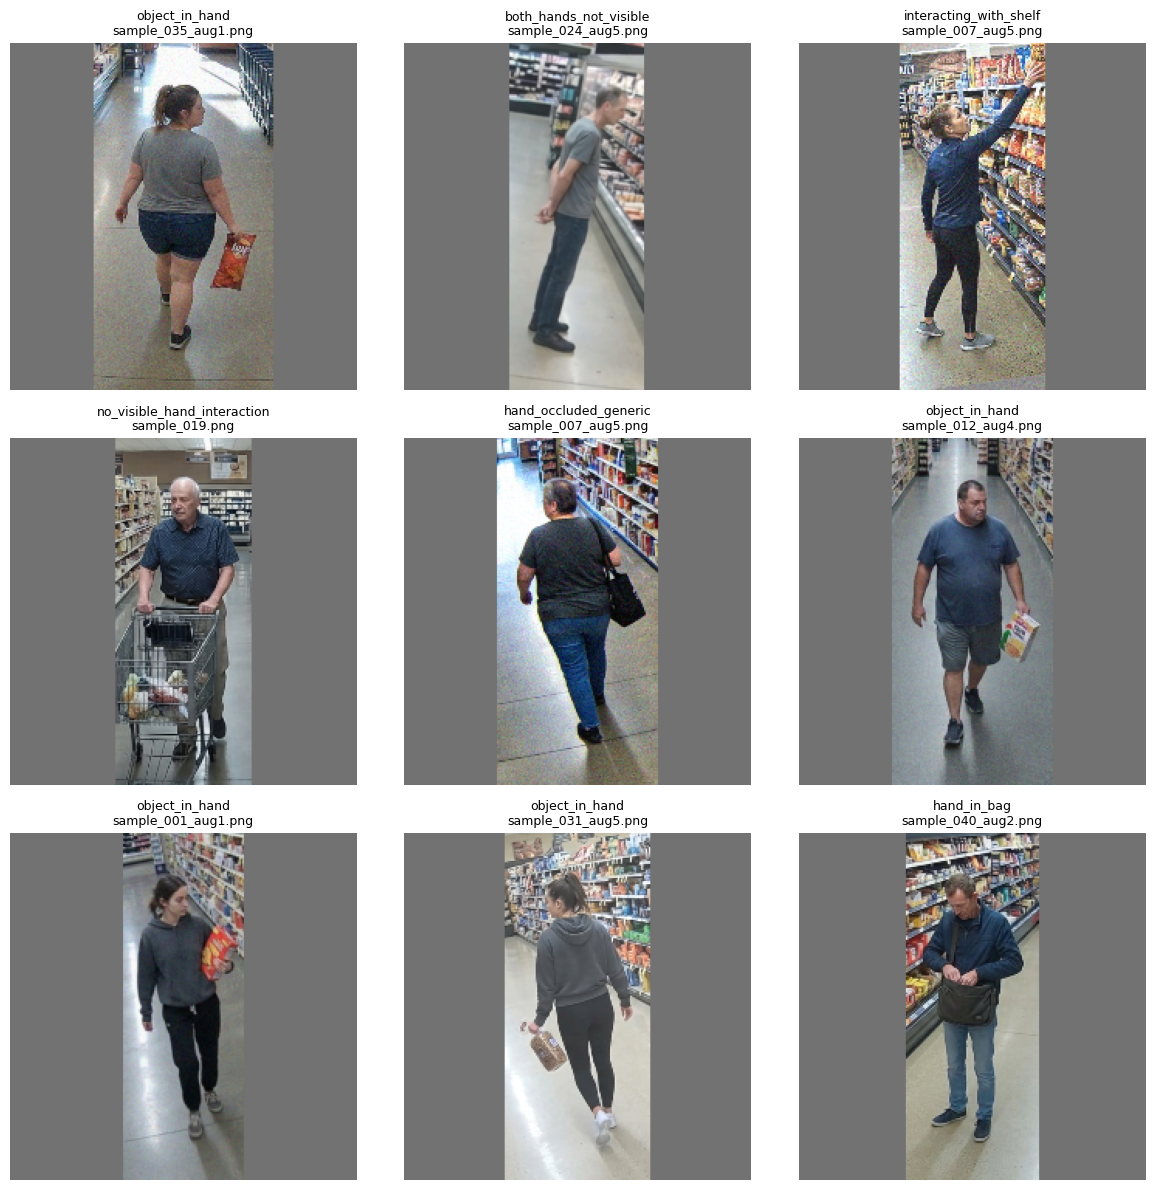

In [22]:
processed_files = sorted(OUTPUT_DIR.rglob("*.png"))
preview = random.sample(processed_files, k=min(9, len(processed_files)))

cols = min(3, len(preview)) or 1
rows = int(np.ceil(len(preview) / cols)) if preview else 1

plt.figure(figsize=(4 * cols, 4 * rows))
for i, path in enumerate(preview):
    img = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{path.parent.name}\n{path.name}", fontsize=9)
plt.tight_layout()
plt.show()

In [23]:
from google.colab import drive
import shutil

# 1. חיבור ה-Google Drive למחברת
drive.mount('/content/drive')

source_folder = '/content/Data_Images_processed'
destination_zip = '/content/drive/MyDrive/Data_Images_processed'

shutil.make_archive(destination_zip, 'zip', source_folder)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'/content/drive/MyDrive/Data_Images_processed.zip'

In [13]:
import shutil
import os

folders_to_delete = [
    '/content/Data_Images_extracted',
    '/content/Data_Images_processed'
]

for folder in folders_to_delete:
    if os.path.exists(folder):
        print(f"Delete: {folder}...")
        shutil.rmtree(folder)
    else:
        print(f"התיקייה {folder} לא קיימת, אין מה למחוק.")



מוחק את התיקייה: /content/Data_Images_extracted...
התיקייה /content/Data_Images_extracted נמחקה בהצלחה.
מוחק את התיקייה: /content/Data_Images_processed...
התיקייה /content/Data_Images_processed נמחקה בהצלחה.

תהליך המחיקה הסתיים.
